In [8]:
import os
import glob
import random
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Import tensorflow and its modules
import tensorflow as tf
from tensorflow import keras # this allows <keras.> instead of <tf.keras.>
from tensorflow.keras import layers # this allows <layers.> instead of <tf.keras.layers.>
tf.keras.utils.set_random_seed(111) # set random seed

# To supress any warnings during the flow
import warnings
warnings.filterwarnings('ignore')

- Image Similarity
- PCA - dimensionality reduction (revise)
- KNN 
- t-SNE

In [2]:
!mkdir -p data
!pip install gdown
!gdown https://drive.google.com/uc?id=137RyRjvTBkBiIfeYBNZBtViDHQ6_Ewsp --output data/caltech101.tar.gz
!tar -xvzf data/caltech101.tar.gz --directory data
!mv data/101_ObjectCategories data/caltech101
!rm -rf data/caltech101/BACKGROUND_Google

     ---------------------------------------- 0.0/78.4 kB ? eta -:--:--
     ---------------------------------------- 0.0/78.4 kB ? eta -:--:--
     ---------------------------------------- 78.4/78.4 kB 4.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=137RyRjvTBkBiIfeYBNZBtViDHQ6_Ewsp

but Gdown can't. Please check connections and permissions.
tar: Error opening archive: Failed to open 'data/caltech101.tar.gz'
'mv' is not recognized as an internal or external command,
operable program or batch file.
'rm' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
!gdown https://drive.google.com/uc?id=137RyRjvTBkBiIfeYBNZBtViDHQ6_Ewsp --output data/caltech101.tar.gz

Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=137RyRjvTBkBiIfeYBNZBtViDHQ6_Ewsp

but Gdown can't. Please check connections and permissions.


- Cosine Similarity works on vectors not matrix.
- If we flatten the image , we cannot get spatial information.

img1 -> CNN -> Emb1
img2 -> CNN -> Emb2

- Cosine Similarity between Emb1 and Emb2 makes more sense

- AlexNet and VVGG 16/19 --> Have high no. of parameters

- Inception Network 
- ResNet

- Inception Network
    - Network inside a network 
    - we want to measure the similarity between the images

- Why cosine similarity and not eucleadian distance?
    - Eucledian distance is not good at higher dimensions
    - Cosine similarity is good at higher dimensions

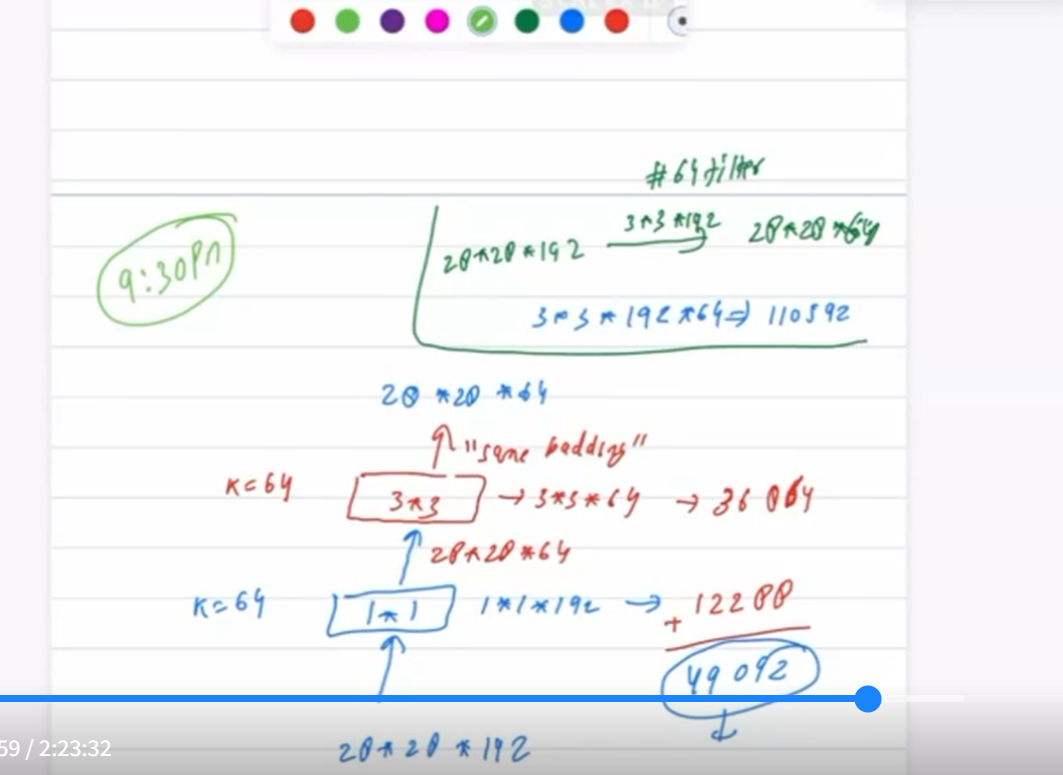

In [6]:
x = 1*1*192*64 + 5*5*64*64
print(x)
y = 5*5*192*64
print(y)

114688
307200


- Because of this (addingn 1x1 conv layer),we are able to reduce the no. of features

# ResNet

- Identity Block
    - 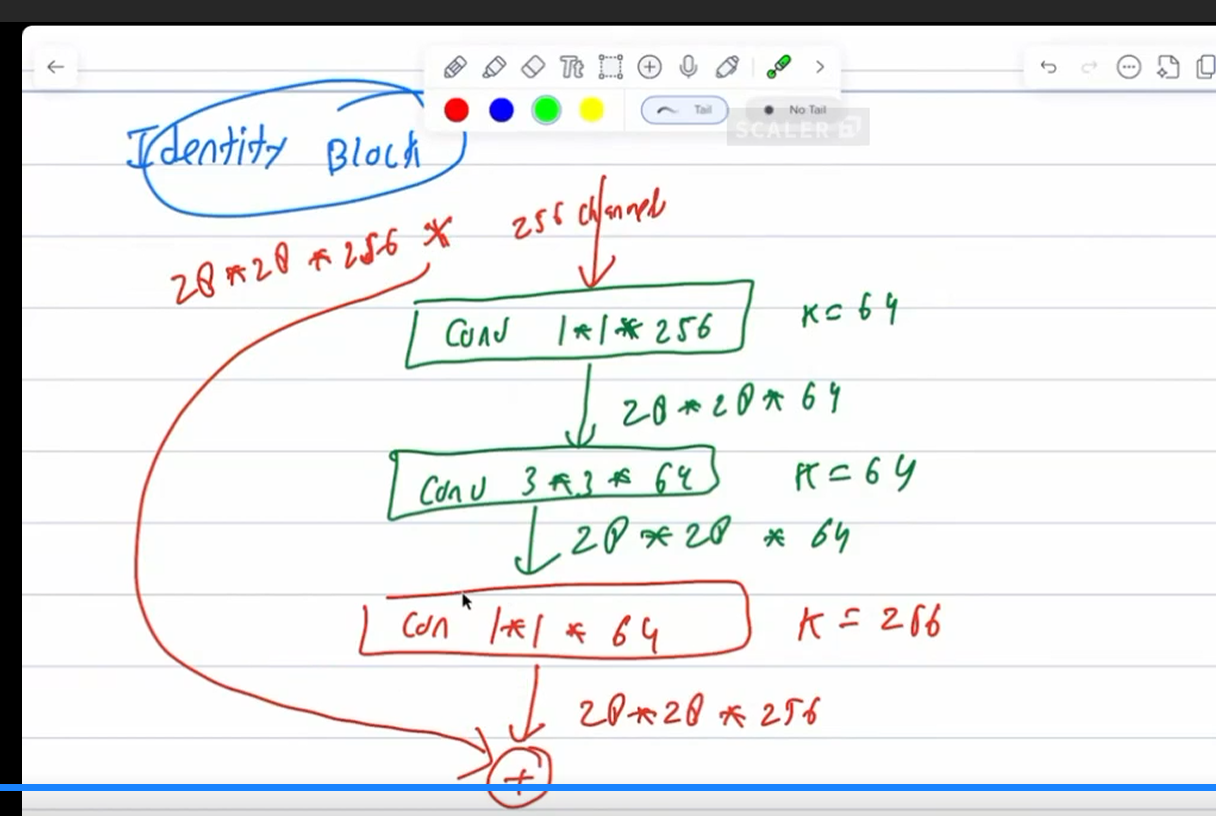

- Similar thing is done in ResNet(adding 1x1 conv layer like Inception Network) to reduce the number of parameters.
- Here we also do skip connections

- If we consider a ResNet block as f(x)
- the output of the block **f(x) is the sum of convolutional path C(x) and the skip connection (x)**
- Then we can say that, The convolutional path is trained to compute C(x) = f(x) – x,
- the difference between the desired output and the input.
- The authors of the ResNet paper argue that this “residue” is easier for the network to learn.

- Convolution Block
    - 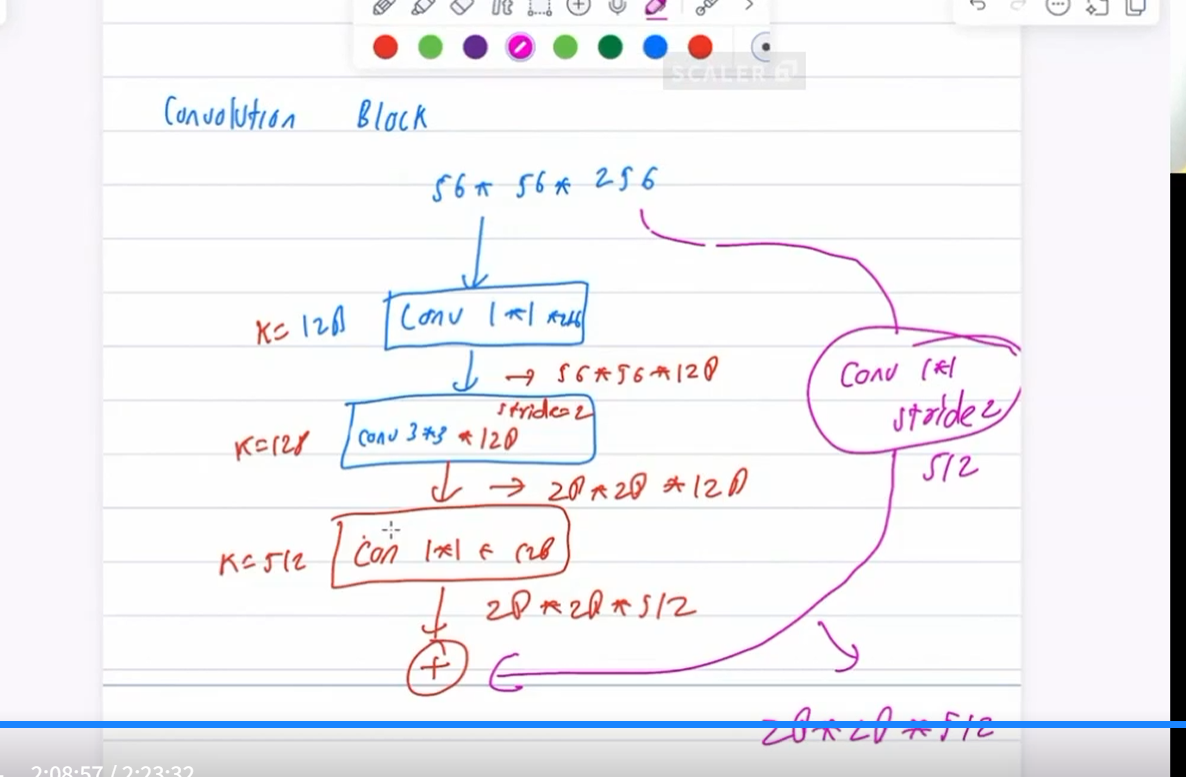

In [9]:
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])

In [12]:
def cs(v1,v2):
    v3 = np.dot(v1,v2)
    mv1 = sum(x**2 for x in v1)**0.5
    mv2 = sum(x**2 for x in v2)**0.5
    return v3/(mv1*mv2)

In [13]:
cs(v1,v2)

np.float64(0.9746318461970762)

- ResNet can help solve vanishing and exploding gradient problems.
- ResNet uses skip connections to allow gradients to flow directly through the network, bypassing some layers.

- X --> [NN] --> H(X) 
- This is how a general neural network works , 
- Instead of predicting H(X0, what if we prefict F(X) = H(X) - X (i/e the residual prediction)

- Two blocks
- Identity block and Convolution block

# Identity Block

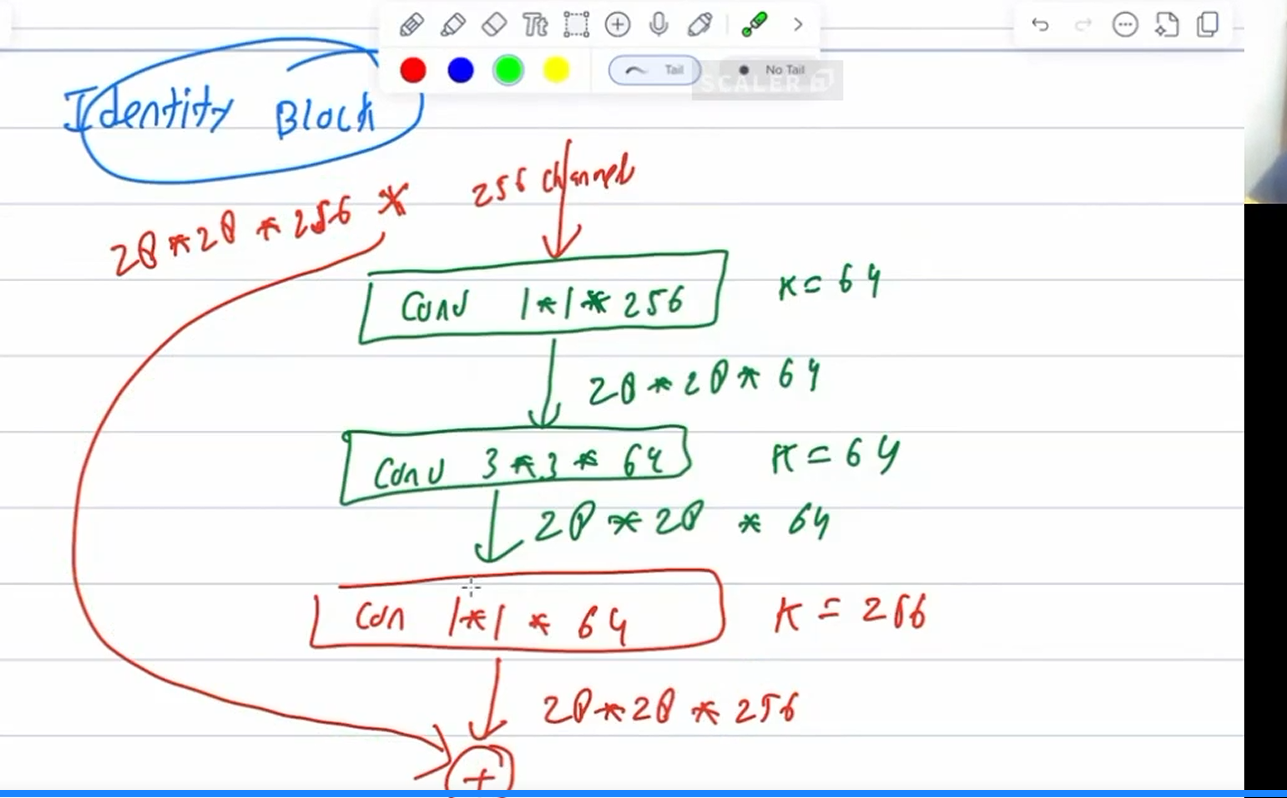

- Since we are adding initial input X() as an identity, we call this identity block

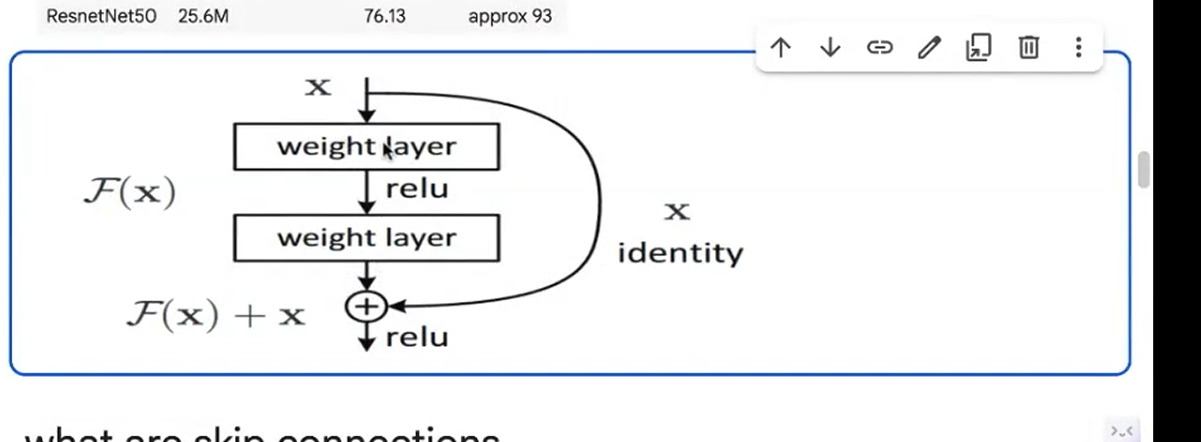

# Convolution Block

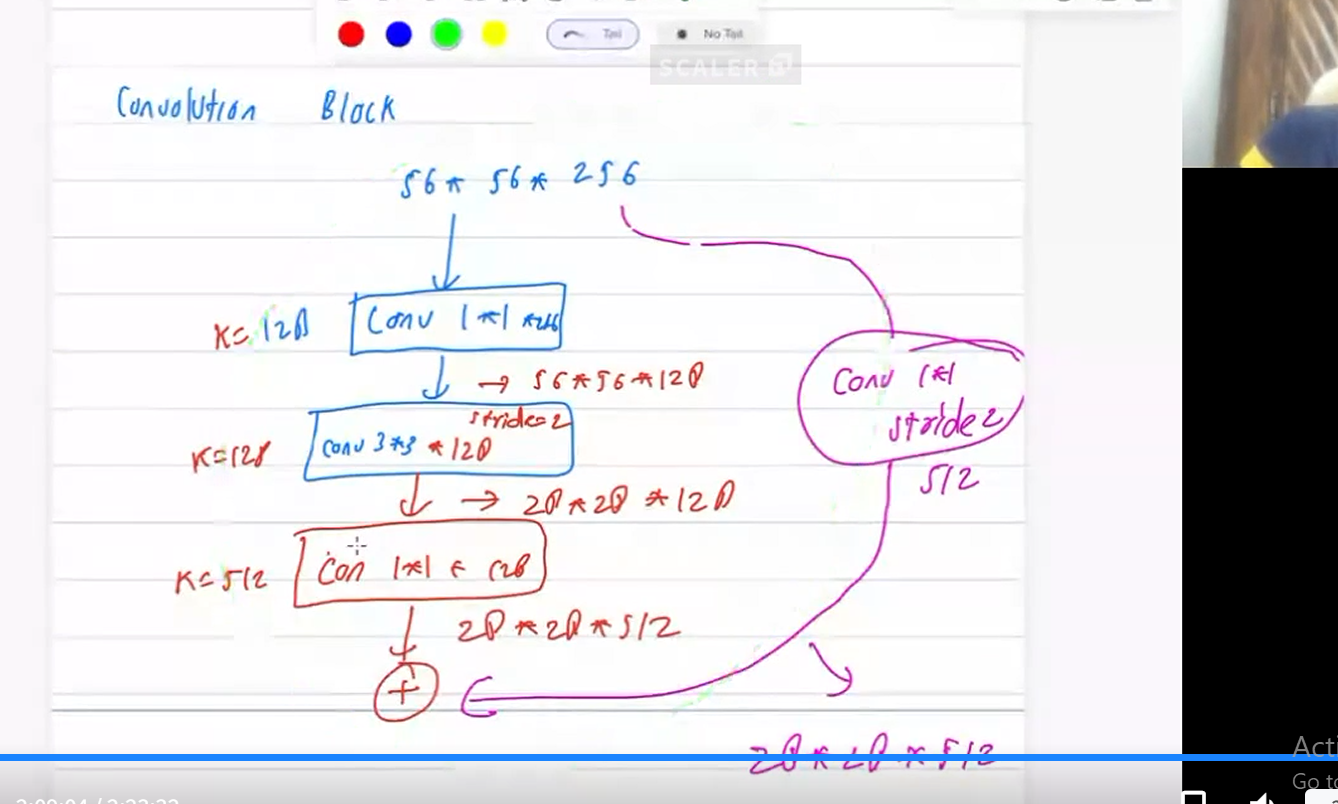

- Identity block is where we can add the x (ORIGINAL) Directly to the output of the 3x3 conv layers
- Conv block is where we can't add the x (ORIGINAL) Directly to the output of the 3x3 conv layers

- Using Resnet , we will generate emberddings